# 07 A/B Swap Ablation Experiment

Compare four TF-IDF Logistic Regression settings: A, A+B, A+C, and A+B+C. The same train/valid split is used for every experiment, and the validation set is never train-augmented.

## 1. Imports and Path Setup

Set up libraries, constants, project paths, and output directories.

In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
LABELS = [0, 1, 2]
LABEL_NAME_MAP = {0: 'A_win', 1: 'B_win', 2: 'tie'}
TARGET_NAMES = [LABEL_NAME_MAP[label] for label in LABELS]

current_dir = Path.cwd().resolve()
if current_dir.name.lower() == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

processed_data_dir = project_root / 'data' / 'processed'
figures_dir = project_root / 'outputs' / 'figures'
logs_dir = project_root / 'outputs' / 'logs'

figures_dir.mkdir(parents=True, exist_ok=True)
logs_dir.mkdir(parents=True, exist_ok=True)

train_path = processed_data_dir / 'train_eda.csv'
test_path = processed_data_dir / 'test_eda.csv'

print(f'Project root: {project_root}')
print(f'train_eda.csv exists: {train_path.exists()} -> {train_path}')
print(f'test_eda.csv exists: {test_path.exists()} -> {test_path}')

Project root: D:\LLM_Classification_finetuning
train_eda.csv exists: True -> D:\LLM_Classification_finetuning\data\processed\train_eda.csv
test_eda.csv exists: True -> D:\LLM_Classification_finetuning\data\processed\test_eda.csv


## 2. Read Data and Check Columns

Read processed EDA files and validate the columns used by the ablation experiment.

In [2]:
train = pd.read_csv(train_path, encoding='utf-8-sig')
test = pd.read_csv(test_path, encoding='utf-8-sig')

required_train_columns = {
    'id',
    'label',
    'label_name',
    'prompt_clean',
    'response_a_clean',
    'response_b_clean',
}
required_test_columns = {'id', 'prompt_clean', 'response_a_clean', 'response_b_clean'}

missing_train_columns = sorted(required_train_columns - set(train.columns))
missing_test_columns = sorted(required_test_columns - set(test.columns))

if missing_train_columns:
    raise ValueError(f'train_eda.csv missing columns: {missing_train_columns}')
if missing_test_columns:
    raise ValueError(f'test_eda.csv missing columns: {missing_test_columns}')

train['label'] = train['label'].astype(int)

print(f'train shape: {train.shape}')
print(f'test shape: {test.shape}')

print('\nLabel counts:')
display(train['label_name'].value_counts().reindex(TARGET_NAMES))

train shape: (57477, 20)
test shape: (3, 12)

Label counts:


label_name
A_win    20064
B_win    19652
tie      17761
Name: count, dtype: int64

## 3. Helper Functions

Define text construction, A/B swapping, probability alignment, and evaluation helpers.

In [3]:
def build_text_input(df):
    prompt = df['prompt_clean'].fillna('').astype(str)
    response_a = df['response_a_clean'].fillna('').astype(str)
    response_b = df['response_b_clean'].fillna('').astype(str)

    return (
        'Prompt:\n' + prompt
        + '\n\nResponse A:\n' + response_a
        + '\n\nResponse B:\n' + response_b
    )


def swap_ab_dataframe(df):
    swapped = df.copy()
    swapped['response_a_clean'] = df['response_b_clean'].values
    swapped['response_b_clean'] = df['response_a_clean'].values

    if 'label' in swapped.columns:
        swapped['label'] = df['label'].map({0: 1, 1: 0, 2: 2}).astype(int).values
        swapped['label_name'] = swapped['label'].map(LABEL_NAME_MAP)

    return swapped


def align_probabilities(probabilities, classes, labels=LABELS):
    aligned = np.zeros((probabilities.shape[0], len(labels)), dtype=float)
    class_to_position = {int(label): idx for idx, label in enumerate(classes)}

    for output_position, label in enumerate(labels):
        if label in class_to_position:
            aligned[:, output_position] = probabilities[:, class_to_position[label]]

    return aligned


def create_vectorizer():
    return TfidfVectorizer(
        max_features=100000,
        ngram_range=(1, 2),
        min_df=2,
        max_df=0.95,
        sublinear_tf=True,
        strip_accents='unicode',
        dtype=np.float32,
    )


def create_model():
    return LogisticRegression(
        C=0.1,
        max_iter=1000,
        solver='saga',
        n_jobs=-1,
        random_state=RANDOM_STATE,
    )


def evaluate_probabilities(y_true, probabilities):
    predictions = np.argmax(probabilities, axis=1)
    return {
        'valid_log_loss': log_loss(y_true, probabilities, labels=LABELS),
        'valid_accuracy': accuracy_score(y_true, predictions),
        'valid_macro_f1': f1_score(y_true, predictions, average='macro'),
    }


print('Helper functions ready.')

Helper functions ready.


## 4. Fixed Train Validation Split

Create one fixed split and reuse it for all four experiments.

In [4]:
train_split, valid_split = train_test_split(
    train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train['label'],
)

train_split = train_split.reset_index(drop=True)
valid_split = valid_split.reset_index(drop=True)

valid_split['text_input'] = build_text_input(valid_split)
y_valid = valid_split['label'].astype(int)

print(f'train_split shape: {train_split.shape}')
print(f'valid_split shape: {valid_split.shape}')

print('\nTrain split label counts:')
display(train_split['label_name'].value_counts().reindex(TARGET_NAMES))

print('\nValid split label counts:')
display(valid_split['label_name'].value_counts().reindex(TARGET_NAMES))

train_split shape: (45981, 20)
valid_split shape: (11496, 21)

Train split label counts:


label_name
A_win    16051
B_win    15721
tie      14209
Name: count, dtype: int64


Valid split label counts:


label_name
A_win    4013
B_win    3931
tie      3552
Name: count, dtype: int64

## 5. Ablation Runner

Run one ablation configuration with optional train-time swap augmentation and optional eval-time swap averaging.

In [5]:
def run_ablation_experiment(experiment_name, use_train_swap=False, use_eval_swap=False):
    if use_train_swap:
        original_train = train_split.copy()
        swapped_train = swap_ab_dataframe(original_train)
        experiment_train = pd.concat([original_train, swapped_train], ignore_index=True)
        experiment_train = experiment_train.sample(frac=1.0, random_state=RANDOM_STATE).reset_index(drop=True)
    else:
        experiment_train = train_split.copy()

    experiment_train['text_input'] = build_text_input(experiment_train)

    vectorizer = create_vectorizer()
    X_train = vectorizer.fit_transform(experiment_train['text_input'])
    X_valid = vectorizer.transform(valid_split['text_input'])
    y_train = experiment_train['label'].astype(int)

    model = create_model()
    model.fit(X_train, y_train)

    valid_prob_raw = model.predict_proba(X_valid)
    valid_prob_original = align_probabilities(valid_prob_raw, model.classes_, LABELS)

    if use_eval_swap:
        valid_swapped = swap_ab_dataframe(valid_split.copy())
        valid_swapped['text_input'] = build_text_input(valid_swapped)
        X_valid_swapped = vectorizer.transform(valid_swapped['text_input'])
        valid_swapped_prob_raw = model.predict_proba(X_valid_swapped)
        valid_swapped_prob = align_probabilities(valid_swapped_prob_raw, model.classes_, LABELS)
        mapped_valid_swapped_prob = np.column_stack([
            valid_swapped_prob[:, 1],
            valid_swapped_prob[:, 0],
            valid_swapped_prob[:, 2],
        ])
        valid_prob = 0.5 * valid_prob_original + 0.5 * mapped_valid_swapped_prob
    else:
        valid_prob = valid_prob_original

    metrics = evaluate_probabilities(y_valid, valid_prob)
    metrics.update({
        'experiment': experiment_name,
        'use_train_swap': use_train_swap,
        'use_eval_swap': use_eval_swap,
        'train_rows': len(experiment_train),
        'valid_rows': len(valid_split),
    })

    print(
        f"{experiment_name}: "
        f"log_loss={metrics['valid_log_loss']:.6f}, "
        f"accuracy={metrics['valid_accuracy']:.6f}, "
        f"macro_f1={metrics['valid_macro_f1']:.6f}, "
        f"train_rows={metrics['train_rows']}"
    )

    return metrics


print('Ablation runner ready.')

Ablation runner ready.


## 6. Run Four Ablation Experiments

Compare A, A+B, A+C, and A+B+C with identical TF-IDF and Logistic Regression parameters.

In [6]:
ablation_configs = [
    {'experiment': 'A', 'description': 'TF-IDF + Logistic Regression tuned', 'use_train_swap': False, 'use_eval_swap': False},
    {'experiment': 'A+B', 'description': 'TF-IDF + Logistic Regression + train-time A/B swap augmentation', 'use_train_swap': True, 'use_eval_swap': False},
    {'experiment': 'A+C', 'description': 'TF-IDF + Logistic Regression + eval-time swap averaging', 'use_train_swap': False, 'use_eval_swap': True},
    {'experiment': 'A+B+C', 'description': 'TF-IDF + Logistic Regression + train-time A/B swap augmentation + eval-time swap averaging', 'use_train_swap': True, 'use_eval_swap': True},
]

ablation_results = []

for config in ablation_configs:
    result = run_ablation_experiment(
        experiment_name=config['experiment'],
        use_train_swap=config['use_train_swap'],
        use_eval_swap=config['use_eval_swap'],
    )
    result['description'] = config['description']
    ablation_results.append(result)

ablation_results_df = pd.DataFrame(ablation_results)
ablation_results_df = ablation_results_df[
    [
        'experiment',
        'description',
        'use_train_swap',
        'use_eval_swap',
        'valid_log_loss',
        'valid_accuracy',
        'valid_macro_f1',
        'train_rows',
        'valid_rows',
    ]
]

display(ablation_results_df)

A: log_loss=1.080877, accuracy=0.385264, macro_f1=0.383576, train_rows=45981
A+B: log_loss=1.078106, accuracy=0.395442, macro_f1=0.396300, train_rows=91962
A+C: log_loss=1.079799, accuracy=0.388570, macro_f1=0.382617, train_rows=45981
A+B+C: log_loss=1.078095, accuracy=0.396834, macro_f1=0.390631, train_rows=91962


,experiment,description,use_train_swap,use_eval_swap,valid_log_loss,valid_accuracy,valid_macro_f1,train_rows,valid_rows
0,A,TF-IDF + Logistic Regression tuned,False,False,1.080877,0.385264,0.383576,45981,11496
1,A+B,TF-IDF + Logistic Regression + train-time A/B swap augmentation,True,False,1.078106,0.395442,0.396300,91962,11496
2,A+C,TF-IDF + Logistic Regression + eval-time swap averaging,False,True,1.079799,0.388570,0.382617,45981,11496
3,A+B+C,TF-IDF + Logistic Regression + train-time A/B swap augmentation + eval-time swap averaging,True,True,1.078095,0.396834,0.390631,91962,11496


## 7. Save Results

Save ablation metrics to `outputs/logs/ablation_ab_swap_results.csv`.

In [7]:
ablation_results_path = logs_dir / 'ablation_ab_swap_results.csv'
ablation_results_df.to_csv(ablation_results_path, index=False, encoding='utf-8-sig')

print(f'Saved ablation results: {ablation_results_path}')
display(ablation_results_df.sort_values('valid_log_loss'))

Saved ablation results: D:\LLM_Classification_finetuning\outputs\logs\ablation_ab_swap_results.csv


,experiment,description,use_train_swap,use_eval_swap,valid_log_loss,valid_accuracy,valid_macro_f1,train_rows,valid_rows
3,A+B+C,TF-IDF + Logistic Regression + train-time A/B swap augmentation + eval-time swap averaging,True,True,1.078095,0.396834,0.390631,91962,11496
1,A+B,TF-IDF + Logistic Regression + train-time A/B swap augmentation,True,False,1.078106,0.395442,0.396300,91962,11496
2,A+C,TF-IDF + Logistic Regression + eval-time swap averaging,False,True,1.079799,0.388570,0.382617,45981,11496
0,A,TF-IDF + Logistic Regression tuned,False,False,1.080877,0.385264,0.383576,45981,11496


## 8. Plot Validation Log Loss

Save a bar chart comparing validation log loss across the four ablation settings.

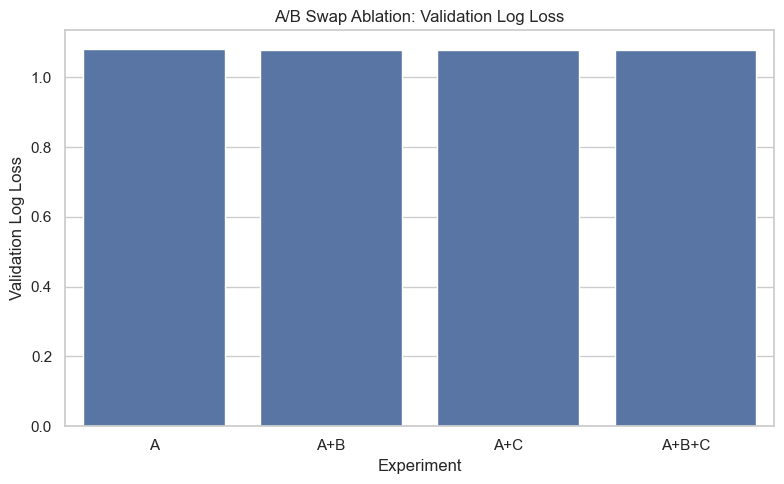

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\ablation_ab_swap_log_loss.png


In [8]:
plt.figure(figsize=(8, 5))
sns.barplot(
    data=ablation_results_df,
    x='experiment',
    y='valid_log_loss',
    order=['A', 'A+B', 'A+C', 'A+B+C'],
)
plt.title('A/B Swap Ablation: Validation Log Loss')
plt.xlabel('Experiment')
plt.ylabel('Validation Log Loss')
plt.tight_layout()

ablation_log_loss_path = figures_dir / 'ablation_ab_swap_log_loss.png'
plt.savefig(ablation_log_loss_path, dpi=150)
plt.show()

print(f'Saved figure: {ablation_log_loss_path}')

## 9. Final Checks

Print the saved outputs and finish message.

In [9]:
print('Saved outputs:')
for path in [ablation_results_path, ablation_log_loss_path]:
    print(f'{path.exists()} -> {path}')

print('\nBest experiment by valid_log_loss:')
display(ablation_results_df.sort_values('valid_log_loss').head(1))

print('A/B swap ablation experiment finished successfully.')

Saved outputs:
True -> D:\LLM_Classification_finetuning\outputs\logs\ablation_ab_swap_results.csv
True -> D:\LLM_Classification_finetuning\outputs\figures\ablation_ab_swap_log_loss.png

Best experiment by valid_log_loss:


,experiment,description,use_train_swap,use_eval_swap,valid_log_loss,valid_accuracy,valid_macro_f1,train_rows,valid_rows
3,A+B+C,TF-IDF + Logistic Regression + train-time A/B swap augmentation + eval-time swap averaging,True,True,1.078095,0.396834,0.390631,91962,11496


A/B swap ablation experiment finished successfully.
